In [1]:
import requests
import re
import os

In [2]:
base_url = "https://www.kgs.ku.edu/Mathgeo/Books/Stat/"
page_url = base_url + "ascii.html"

output_dir = "kgs_ascii_data"
os.makedirs(output_dir, exist_ok=True)

# Fetch page
response = requests.get(page_url)
response.raise_for_status()
text = response.text

# Extract all .TXT filenames using regex
txt_files = re.findall(r'\b[A-Z0-9_]+\.TXT\b', text)

# Remove duplicates
txt_files = list(set(txt_files))

print(f"Found {len(txt_files)} files.")

# Download
for file_name in txt_files:
    file_url = base_url + file_name
    save_path = os.path.join(output_dir, file_name)

    try:
        r = requests.get(file_url)
        r.raise_for_status()

        with open(save_path, "wb") as f:
            f.write(r.content)

        print(f"Downloaded: {file_name}")

    except Exception as e:
        print(f"Failed: {file_name} ({e})")

print("Done.")

Found 127 files.
Failed: BANGLA.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/BANGLA.TXT)
Failed: GREENRIV.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/GREENRIV.TXT)
Failed: KANSALT.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/KANSALT.TXT)
Failed: CONO.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/CONO.TXT)
Failed: GRAHAM.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/GRAHAM.TXT)
Failed: COLLIERY.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/COLLIERY.TXT)
Failed: FACTOR.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/FACTOR.TXT)
Failed: CARBONAT.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Mathgeo/Books/Stat/CARBONAT.TXT)
Failed: MIDLAND.TXT (404 Client Error: Not Found for url: https://www.kgs.ku.edu/Math

In [5]:
import requests
import re
import os
import time

# Page with file list
page_url = "https://www.kgs.ku.edu/Mathgeo/Books/Stat/ascii.html"

# Correct download base
download_base = "https://www.kgs.ku.edu/Mathgeo/Books/Stat/ASCII/"

# Output folder
output_dir = "kgs_ascii_data"
os.makedirs(output_dir, exist_ok=True)

# Fetch page
response = requests.get(page_url)
response.raise_for_status()

# Extract filenames
txt_files = re.findall(r'\b[A-Z0-9_]+\.TXT\b', response.text)
txt_files = list(set(txt_files))

print(f"Found {len(txt_files)} files.")

# Download each file
for file_name in txt_files:
    file_url = download_base + file_name
    save_path = os.path.join(output_dir, file_name)

    # Skip if already downloaded
    if os.path.exists(save_path):
        print(f"Skipping (exists): {file_name}")
        continue

    try:
        r = requests.get(file_url)
        r.raise_for_status()

        with open(save_path, "wb") as f:
            f.write(r.content)

        print(f"Downloaded: {file_name}")

        time.sleep(0.2)  # be polite

    except Exception as e:
        print(f"Failed: {file_name} ({e})")

print("Done.")

Found 127 files.
Downloaded: BANGLA.TXT
Downloaded: GREENRIV.TXT
Downloaded: KANSALT.TXT
Downloaded: CONO.TXT
Downloaded: GRAHAM.TXT
Downloaded: COLLIERY.TXT
Downloaded: FACTOR.TXT
Downloaded: CARBONAT.TXT
Downloaded: MIDLAND.TXT
Downloaded: SONORA.TXT
Downloaded: WHITE.TXT
Downloaded: ARSENAL.TXT
Downloaded: PROFILE.TXT
Downloaded: BANK.TXT
Downloaded: DRAWDOWN.TXT
Downloaded: LODGEPOL.TXT
Downloaded: TONGA.TXT
Downloaded: CELTIC.TXT
Downloaded: WASATCH.TXT
Downloaded: ARBUCKLE.TXT
Downloaded: GLOMAR.TXT
Downloaded: ODESSANW.TXT
Downloaded: LUNARBAS.TXT
Downloaded: QMODE.TXT
Downloaded: COOPERD.TXT
Downloaded: CROPB.TXT
Downloaded: BIVARIAT.TXT
Downloaded: HEULAND.TXT
Downloaded: CROATRAD.TXT
Downloaded: EISENERZ.TXT
Downloaded: BARATARA.TXT
Downloaded: ANDES.TXT
Downloaded: BRINE.TXT
Downloaded: SPHALRT.TXT
Downloaded: OKLA.TXT
Downloaded: RESSEREL.TXT
Downloaded: ORTHID.TXT
Downloaded: WATER.TXT
Downloaded: COBALT.TXT
Downloaded: HGCURVE.TXT
Downloaded: AGUACAL.TXT
Downloaded: WELLW

In [6]:
# Read a data from link
import pandas as pd
import requests
import os
from io import StringIO

def load_kgs_data(name, save_dir="kgs_ascii_data", force_download=False):
    """
    Load a KGS ASCII dataset into a pandas DataFrame.

    Parameters:
        name (str): Dataset name (e.g., 'ABOC' or 'ABOC.TXT')
        save_dir (str): Directory to store downloaded files
        force_download (bool): If True, re-download even if file exists

    Returns:
        pd.DataFrame
    """

    # Normalize filename
    if not name.upper().endswith(".TXT"):
        filename = name.upper() + ".TXT"
    else:
        filename = name.upper()

    os.makedirs(save_dir, exist_ok=True)
    filepath = os.path.join(save_dir, filename)

    # Download if needed
    if force_download or not os.path.exists(filepath):
        url = f"https://www.kgs.ku.edu/Mathgeo/Books/Stat/ASCII/{filename}"
        response = requests.get(url)
        response.raise_for_status()

        with open(filepath, "w", encoding="utf-8") as f:
            f.write(response.text)

    # Read file content
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()

    # Try different parsing strategies
    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(StringIO(content), sep=sep, engine="python")
            if df.shape[1] > 1:  # reasonable parse
                return df
        except Exception:
            continue

    # Fallback: single column
    return pd.DataFrame({"raw": content.splitlines()}) 

In [15]:
df = load_kgs_data("ZEOLITES")
print(df.shape)
print(df.head())
print(df.info())

(301, 13)
  Zeolite  Origin  Group   Na    K   Mg   Ca   Sr   Ba  Fe+++    Al    Si  \
0       1     1.0    1.0  3.6  0.9  1.1  7.8  0.1  0.1    0.1  22.2  77.4   
1       1     1.0    1.0  4.3  0.6  1.1  8.2  0.1  0.1    0.2  22.9  76.7   
2       1     1.0    1.0  3.0  0.7  0.6  6.6  0.2  0.2    0.4  19.2  80.4   
3       1     1.0    1.0  3.1  6.9  2.4  4.7  0.1  0.2    0.1  22.3  77.0   
4       1     1.0    1.0  0.8  3.0  1.0  6.0  0.1  0.7    0.8  18.6  80.7   

    H2O  
0  75.0  
1  68.2  
2  67.0  
3  67.3  
4  78.4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Zeolite  301 non-null    object 
 1   Origin   299 non-null    float64
 2   Group    299 non-null    float64
 3   Na       299 non-null    float64
 4   K        299 non-null    float64
 5   Mg       299 non-null    float64
 6   Ca       299 non-null    float64
 7   Sr       299 no

In [ ]:
df = load_kgs_data("ZEOLITES")

In [16]:
import pandas as pd
import os

def load_kgs_local(name, data_dir="kgs_ascii_data"):
    """
    Load a KGS ASCII dataset from local directory into pandas.

    Parameters:
        name (str): Dataset name (e.g., 'ABOC' or 'ABOC.TXT')
        data_dir (str): Directory where files are stored

    Returns:
        pd.DataFrame
    """

    # Normalize filename
    if not name.upper().endswith(".TXT"):
        filename = name.upper() + ".TXT"
    else:
        filename = name.upper()

    filepath = os.path.join(data_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"{filepath} not found")

    # Try multiple parsing strategies
    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(filepath, sep=sep, engine="python")

            # Heuristic: if it produces multiple columns, it's probably correct
            if df.shape[1] > 1:
                return df

        except Exception:
            continue

    # Fallback: read as raw lines
    with open(filepath, "r") as f:
        lines = f.readlines()

    return pd.DataFrame({"raw": [line.strip() for line in lines]})

In [25]:
garnets = load_kgs_local("GARNETS")

print(garnets.head())
print(garnets.shape)

   Depth (cm)   Fe %
0           0  14.21
1           3  19.35
2          10  17.22
3          14  15.87
4          23  13.62
(46, 2)


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

def scatter_plot(df, x, y):
    """
    Simple bivariate scatter plot.

    Parameters:
        df (pd.DataFrame): Data
        x (str): Column for x-axis
        y (str): Column for y-axis
    """

    # Ensure numeric (coerce errors → NaN)
    data = df[[x, y]].apply(pd.to_numeric, errors='coerce').dropna()

    plt.figure(figsize=(6, 4))
    plt.scatter(data[x], data[y])

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")

    plt.show()

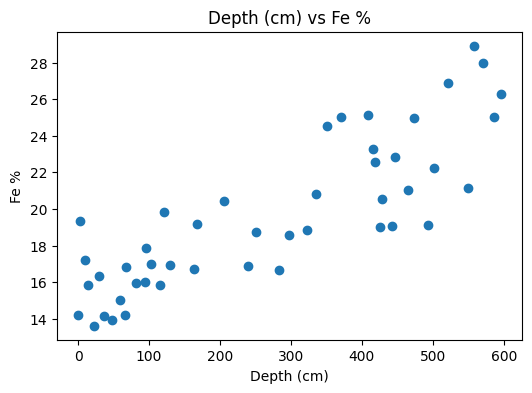

In [30]:
scatter_plot(garnets, "Depth (cm)", "Fe %")

In [26]:
zeolites = load_kgs_local("ZEOLITES")

print(zeolites.head())
print(zeolites.shape)

  Zeolite  Origin  Group   Na    K   Mg   Ca   Sr   Ba  Fe+++    Al    Si  \
0       1     1.0    1.0  3.6  0.9  1.1  7.8  0.1  0.1    0.1  22.2  77.4   
1       1     1.0    1.0  4.3  0.6  1.1  8.2  0.1  0.1    0.2  22.9  76.7   
2       1     1.0    1.0  3.0  0.7  0.6  6.6  0.2  0.2    0.4  19.2  80.4   
3       1     1.0    1.0  3.1  6.9  2.4  4.7  0.1  0.2    0.1  22.3  77.0   
4       1     1.0    1.0  0.8  3.0  1.0  6.0  0.1  0.7    0.8  18.6  80.7   

    H2O  
0  75.0  
1  68.2  
2  67.0  
3  67.3  
4  78.4  
(301, 13)


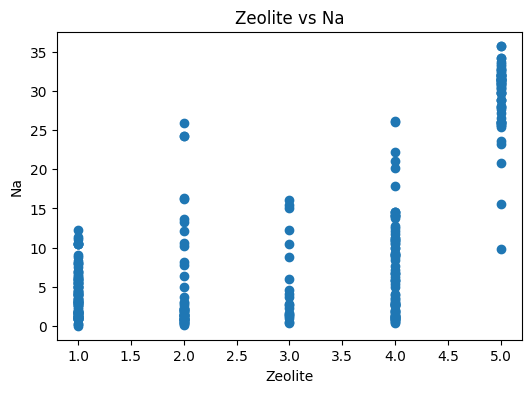

In [32]:
scatter_plot(zeolites, "Zeolite", "Na")

# LOUISMUD would be good example for parsing

In [34]:
louismud = pd.read_csv(
    "kgs_ascii_data/LOUISMUD.TXT",
    sep="\t"
)

# Clean column names
louismud.columns = [
    "Depth_ft",
    "Moisture",
    "Core"
]

print(louismud.head())

   Depth_ft  Moisture  Core
0         0       124     1
1         5        78     1
2        10        54     1
3        15        35     1
4        20        30     1


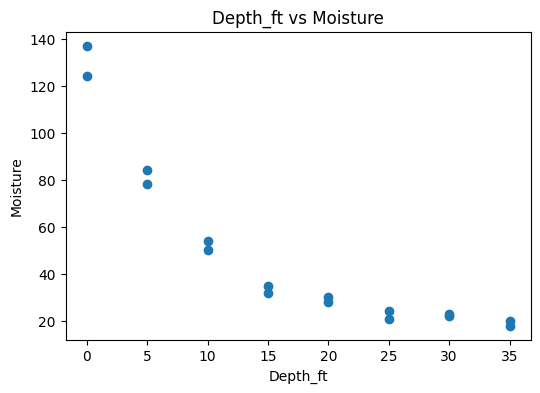

In [35]:
scatter_plot(louismud, "Depth_ft", "Moisture")

In [41]:
sands = pd.read_csv(
        filepath,
        sep="\t",
        skiprows=1,   # skip the descriptive header
        header=None
    )

In [46]:
sands = pd.read_csv("kgs_ascii_data/SANDS.TXT", sep="\t", skiprows=1, header=None)
# Assign correct column names
sands.columns = [
    "Group",
    "Median_grain_size_mm",
    "Sorting_coefficient"
]
print(sands.head())
print(sands.shape)

  Group  Median_grain_size_mm  Sorting_coefficient
0     A                 0.333                 1.08
1     A                 0.340                 1.08
2     A                 0.338                 1.09
3     A                 0.333                 1.10
4     A                 0.323                 1.13
(81, 3)


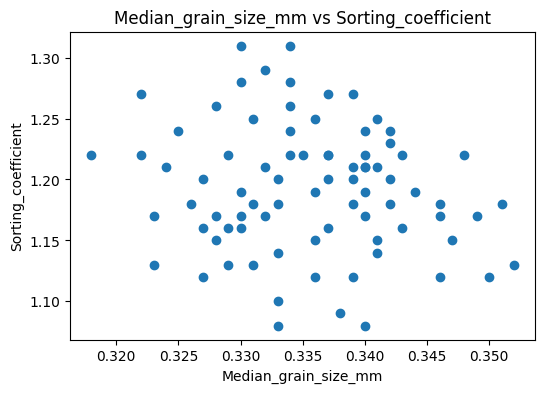

In [48]:
scatter_plot(sands, "Median_grain_size_mm", "Sorting_coefficient")

In [49]:
import matplotlib.pyplot as plt

def scatter_plot_colored(df, x, y, color_col=None, cmap="viridis"):
    """
    Scatter plot with optional color coding by a 3rd column.

    Parameters:
        df (pd.DataFrame): The data
        x (str): Column name for x-axis
        y (str): Column name for y-axis
        color_col (str): Optional column for coloring points
        cmap (str): Colormap for numeric color column
    """

    plt.figure(figsize=(6, 4))

    if color_col is None:
        plt.scatter(df[x], df[y])
    else:
        # If the color column is numeric, use colormap
        if pd.api.types.is_numeric_dtype(df[color_col]):
            plt.scatter(df[x], df[y], c=df[color_col], cmap=cmap)
            plt.colorbar(label=color_col)
        else:
            # If categorical, map each category to a color
            categories = df[color_col].astype('category')
            for cat in categories.cat.categories:
                subset = df[df[color_col] == cat]
                plt.scatter(subset[x], subset[y], label=str(cat))
            plt.legend(title=color_col)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.show()

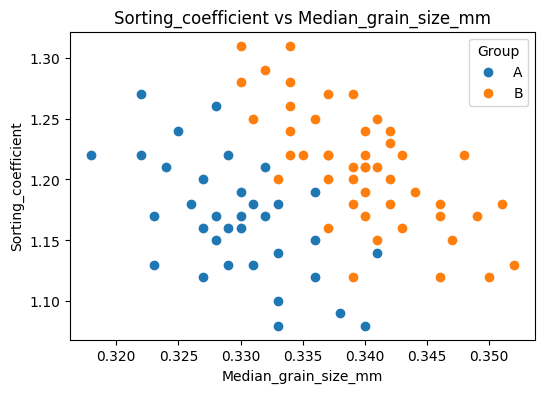

In [52]:
scatter_plot_colored(sands, "Median_grain_size_mm", "Sorting_coefficient", color_col="Group")

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

def classify_sands(df, feature_cols, target_col="Group", test_size=0.3, random_state=42):
    """
    Train multiple classifiers to discriminate Group A/B using given features.

    Parameters:
        df (pd.DataFrame): dataset
        feature_cols (list): list of 2 feature column names
        target_col (str): name of target column
        test_size (float): train-test split
        random_state (int): reproducibility

    Returns:
        dict of trained models with accuracy scores
    """

    # Prepare data
    X = df[feature_cols].values
    y = df[target_col].values

    # Encode target if categorical
    le = LabelEncoder()
    y_enc = le.fit_transform(y)  # A/B -> 0/1

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state
    )

    # Scale features for SVM & Linear methods
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define models
    models = {
        "Logistic Regression": LogisticRegression(),
        "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
        "SVM (RBF)": SVC(kernel="rbf", probability=True),
        "Decision Tree": DecisionTreeClassifier(random_state=random_state)
    }

    results = {}

    for name, model in models.items():
        # Scale only for linear / SVM models
        if name in ["Logistic Regression", "Linear Discriminant Analysis", "SVM (RBF)"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results[name] = {"model": model, "accuracy": acc, "y_pred": y_pred}

        print(f"{name}: Accuracy = {acc:.2f}")
        print(confusion_matrix(y_test, y_pred))
        print("-" * 30)

    return results, scaler, le, X_train_scaled, X_test_scaled, y_train, y_test

In [55]:
features = ["Median_grain_size_mm", "Sorting_coefficient"]

results, scaler, le, X_train_scaled, X_test_scaled, y_train, y_test = classify_sands(sands, features)

Logistic Regression: Accuracy = 0.88
[[10  2]
 [ 1 12]]
------------------------------
Linear Discriminant Analysis: Accuracy = 0.84
[[10  2]
 [ 2 11]]
------------------------------
SVM (RBF): Accuracy = 0.88
[[10  2]
 [ 1 12]]
------------------------------
Decision Tree: Accuracy = 0.84
[[ 9  3]
 [ 1 12]]
------------------------------


In [56]:
import numpy as np

def plot_decision_boundaries(models_dict, X, y, feature_names, le, scaler=None, figsize=(12, 10)):
    """
    Plot decision boundaries for multiple classifiers in 2D.

    Parameters:
        models_dict (dict): dictionary of trained models
        X (array-like): features (2D)
        y (array-like): encoded target
        feature_names (list): list of 2 feature column names
        le (LabelEncoder): to decode labels
        scaler: optional StandardScaler used in training
        figsize (tuple): figure size
    """
    h = 0.01  # mesh step size
    n_models = len(models_dict)
    plt.figure(figsize=figsize)

    for i, (name, info) in enumerate(models_dict.items(), 1):
        model = info['model']

        # Use scaled features if scaler is provided
        if scaler is not None and name in ["Logistic Regression", "Linear Discriminant Analysis", "SVM (RBF)"]:
            X_plot = scaler.transform(X)
        else:
            X_plot = X

        # Create mesh grid
        x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
        y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))

        # Predict over the grid
        if scaler is not None and name in ["Logistic Regression", "Linear Discriminant Analysis", "SVM (RBF)"]:
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        else:
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

        Z = Z.reshape(xx.shape)

        # Plot
        plt.subplot(2, 2, i)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        scatter = plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
        plt.xlabel(feature_names[0])
        plt.ylabel(feature_names[1])
        plt.title(name)

        # Legend for classes
        handles, _ = scatter.legend_elements()
        plt.legend(handles, le.inverse_transform([0, 1]), title="Group")

    plt.tight_layout()
    plt.show()

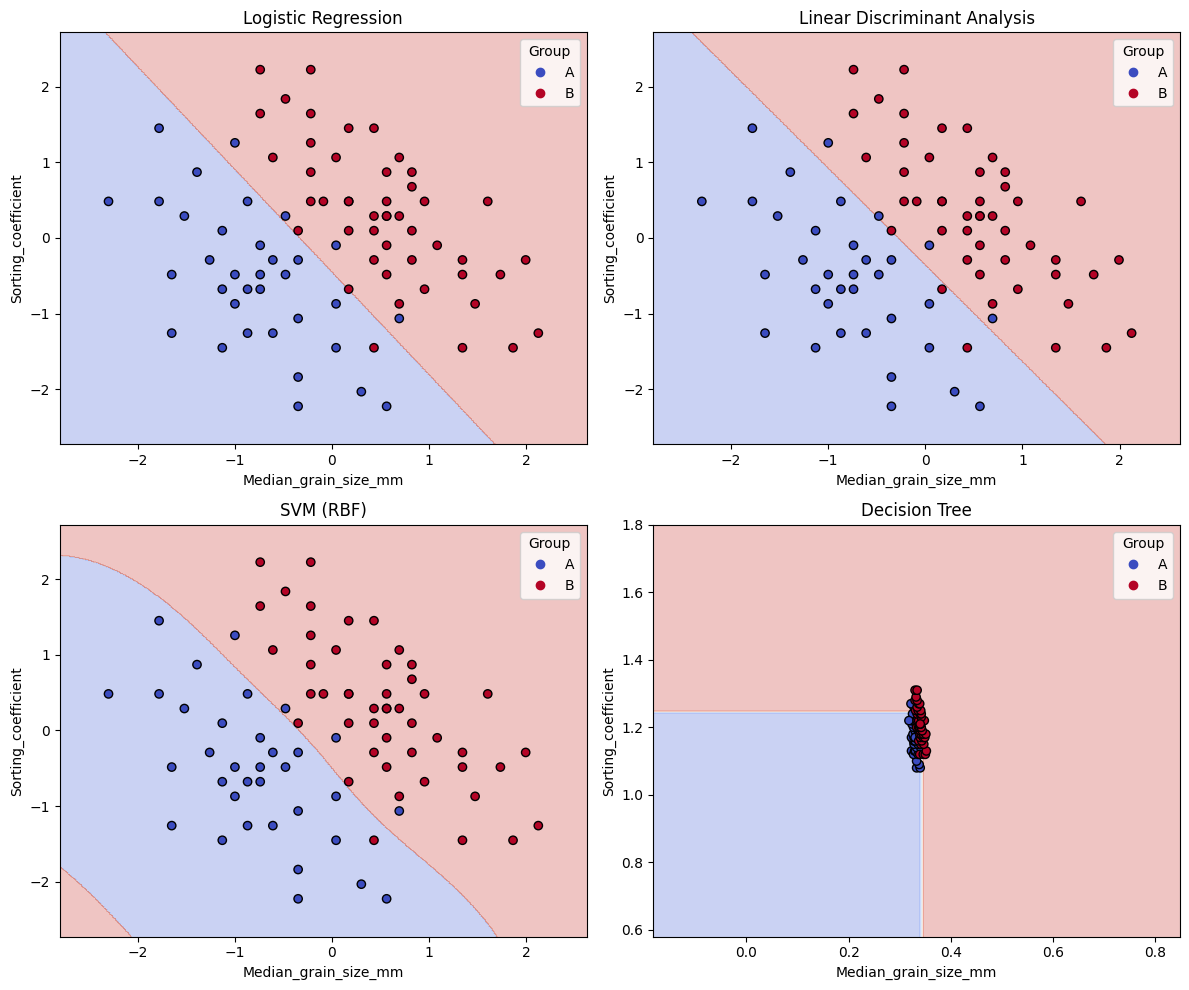

In [57]:
# features and labels
X = sands[features].values
y = le.transform(sands["Group"])

plot_decision_boundaries(results, X, y, features, le, scaler=scaler)